<h1>Code 1:

<h2>Model Architecture

This is a Multi-task Convolutional Neural Network (CNN):

Input Layer:

1. Shape (128,128,1) for grayscale signature images.

2. Shared Feature Extractor (CNN layers):

    3 convolution + max pooling blocks:

          Conv2D(32) → MaxPooling2D

          Conv2D(64) → MaxPooling2D

          Conv2D(128) → MaxPooling2D

   Flatten → Dense(256) → Dropout(0.5).

   Learns common features (strokes, curves, textures, etc.).

3. Branch 1 – Person Identification:

      - Dense layer with num_persons neurons, softmax.

      - Task: "Who signed this signature?"

4. Branch 2 – Forgery Detection:

      - Dense layer with 2 neurons, softmax.

      - Task: "Is this signature Genuine or Forged?"

<h3>Model Compilation

1. Optimizer: Adam.

2. Losses:

     categorical_crossentropy for both branches.

3. Metrics:

     Accuracy for both tasks separately.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# ---------------------------
# 1. Load dataset
# ---------------------------
data = np.load("signatures_dataset.npz", allow_pickle=True)

X = data["X"]                         # (N, 128, 128, 1)
y_person_ids = data["person_ids"]     # person_id (int)
y_person_names = data["person_names"] # person_name (string)
y_genuine = data["is_genuine"]        # 0/1
y_labels = data["labels"]             # any extra label

print("Shapes:", X.shape, y_person_ids.shape, y_genuine.shape)

# ---------------------------
# 2. Encode labels
# ---------------------------
num_persons = len(np.unique(y_person_ids))

y_persons_oh = to_categorical(y_person_ids - 1, num_classes=num_persons)
y_genuine_oh = to_categorical(y_genuine, num_classes=2)

# ---------------------------
# 3. Train/test split
# ---------------------------
X_train, X_test, y_persons_train, y_persons_test, y_genuine_train, y_genuine_test = train_test_split(
    X, y_persons_oh, y_genuine_oh, test_size=0.2, random_state=42, stratify=y_person_ids
)

# ---------------------------
# 4. Define Multi-task CNN
# ---------------------------
inputs = Input(shape=(128, 128, 1))

x = Conv2D(32, (3,3), activation="relu", padding="same")(inputs)
x = MaxPooling2D((2,2))(x)
x = Conv2D(64, (3,3), activation="relu", padding="same")(x)
x = MaxPooling2D((2,2))(x)
x = Conv2D(128, (3,3), activation="relu", padding="same")(x)
x = MaxPooling2D((2,2))(x)
x = Flatten()(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.5)(x)

# Branch 1: Person classification
person_output = Dense(num_persons, activation="softmax", name="person_output")(x)

# Branch 2: Genuine/Forged classification
genuine_output = Dense(2, activation="softmax", name="genuine_output")(x)

# Model
model = Model(inputs=inputs, outputs=[person_output, genuine_output])

model.compile(
    optimizer="adam",
    loss={"person_output": "categorical_crossentropy", "genuine_output": "categorical_crossentropy"},
    metrics={"person_output": "accuracy", "genuine_output": "accuracy"}
)

model.summary()

# ---------------------------
# 5. Train
# ---------------------------
history = model.fit(
    X_train,
    {"person_output": y_persons_train, "genuine_output": y_genuine_train},
    validation_data=(X_test, {"person_output": y_persons_test, "genuine_output": y_genuine_test}),
    epochs=10,
    batch_size=32
)


Shapes: (2640, 128, 128, 1) (2640,) (2640,)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │        320 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_3     │ (None, 64, 64,    │          0 │ conv2d_3[0][0]    │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     18,496 │ max_pooling2d_3[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 32,    │          0 │ conv2d_4[0][0]    │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 32,    │     73,856 │ max_pooling2d_4[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_5     │ (None, 16, 16,    │          0 │ conv2d_5[0][0]    │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 32768)     │          0 │ max_pooling2d_5[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 256)       │  8,388,864 │ flatten_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 256)       │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ person_output       │ (None, 55)        │     14,135 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ genuine_output      │ (None, 2)         │        514 │ dropout_1[0][0]   │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 8,496,185 (32.41 MB)

 Trainable params: 8,496,185 (32.41 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 7s 46ms/step - genuine_output_accuracy: 0.5171 - genuine_output_loss: 0.8874 - loss: 4.9916 - person_output_accuracy: 0.0127 - person_output_loss: 4.1042 - val_genuine_output_accuracy: 0.6799 - val_genuine_output_loss: 0.6181 - val_loss: 4.2405 - val_person_output_accuracy: 0.1705 - val_person_output_loss: 3.6238
Epoch 2/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - genuine_output_accuracy: 0.7011 - genuine_output_loss: 0.6169 - loss: 3.8631 - person_output_accuracy: 0.1716 - person_output_loss: 3.2462 - val_genuine_output_accuracy: 0.6970 - val_genuine_output_loss: 0.5718 - val_loss: 2.5663 - val_person_output_accuracy: 0.5114 - val_person_output_loss: 2.0001
Epoch 3/10
66/66 ━━━━━━━━━━━━━━━━━━━━ 2s 23ms/step - genuine_output_accuracy: 0.7361 - genuine_output_loss: 0.5502 - loss: 2.5569 - person_output_accuracy: 0.4559 - person_output_loss: 2.0067 - val_genuine_output_accuracy: 0.7803 - val_genuine_output_loss: 0.4567 - val_loss: 1.6181 - val_perso

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# ---------------------------
# Evaluate model on test data
# ---------------------------
test_loss, person_loss, genuine_loss, person_acc, genuine_acc = model.evaluate(
    X_test,
    {"person_output": y_persons_test, "genuine_output": y_genuine_test},
    verbose=1
)

print("\n📊 Test Results:")
print(f"Total loss: {test_loss:.4f}")
print(f"Person ID loss: {person_loss:.4f}, Accuracy: {person_acc:.4f}")
print(f"Genuine/Forgery loss: {genuine_loss:.4f}, Accuracy: {genuine_acc:.4f}")


17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - genuine_output_accuracy: 0.8993 - genuine_output_loss: 0.3324 - loss: 0.6061 - person_output_accuracy: 0.9030 - person_output_loss: 0.2771

📊 Test Results:
Total loss: 0.6902
Person ID loss: 0.3488, Accuracy: 0.8902
Genuine/Forgery loss: 0.3731, Accuracy: 0.8902


In [ ]:
# ---------------------------
# Predictions
# ---------------------------
y_pred_person_probs, y_pred_genuine_probs = model.predict(X_test)

# Person predictions
y_pred_person = np.argmax(y_pred_person_probs, axis=1)
y_true_person = np.argmax(y_persons_test, axis=1)

# Genuine predictions
y_pred_genuine = np.argmax(y_pred_genuine_probs, axis=1)
y_true_genuine = np.argmax(y_genuine_test, axis=1)

# ---------------------------
# Reports
# ---------------------------
print("\nPerson ID Classification Report:")
print(classification_report(y_true_person, y_pred_person))

print("\nGenuine/Forgery Classification Report:")
print(classification_report(y_true_genuine, y_pred_genuine))

print("\nConfusion Matrix (Person ID):")
print(confusion_matrix(y_true_person, y_pred_person))

print("\nConfusion Matrix (Genuine/Forgery):")
print(confusion_matrix(y_true_genuine, y_pred_genuine))


17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step

Person ID Classification Report:
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       0.91      1.00      0.95        10
           2       0.89      0.89      0.89         9
           3       0.78      0.78      0.78         9
           4       0.80      0.89      0.84         9
           5       0.82      1.00      0.90         9
           6       1.00      0.40      0.57        10
           7       1.00      1.00      1.00         9
           8       0.83      1.00      0.91        10
           9       1.00      0.90      0.95        10
          10       1.00      0.90      0.95        10
          11       1.00      1.00      1.00         9
          12       1.00      1.00      1.00         9
          13       0.82      0.90      0.86        10
          14       1.00      0.90      0.95        10
          15       1.00      1.00      1.00        10
       

In [ ]:
model.save("signature_verification_model.h5")
print("✅ Model saved as signature_verification_model.h5")


✅ Model saved as signature_verification_model.h5


In [ ]:
from google.colab import files

# Save again (just to be sure)
model.save("signature_verification_model.h5")

# Download to local system
files.download("signature_verification_model.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import cv2
import requests
from io import BytesIO
from PIL import Image

# Mapping person_id → person_name
person_id_to_name = {pid: name for pid, name in zip(y_person_ids, y_person_names)}

def preprocess_single_image(img_path_or_url):
    # Load image from URL or local path
    if img_path_or_url.startswith("http"):
        response = requests.get(img_path_or_url)
        img = Image.open(BytesIO(response.content)).convert("L")  # grayscale
    else:
        img = Image.open(img_path_or_url).convert("L")

    # Resize & normalize
    img = img.resize((128, 128))
    img = np.array(img, dtype="float32") / 255.0
    img = np.expand_dims(img, axis=-1)   # (128,128,1)
    img = np.expand_dims(img, axis=0)    # (1,128,128,1)
    return img

def predict_signature(img_path_or_url):
    img = preprocess_single_image(img_path_or_url)
    pred_person_probs, pred_genuine_probs = model.predict(img)

    # Person
    pred_person_id = np.argmax(pred_person_probs)
    pred_person_name = person_id_to_name.get(pred_person_id+1, f"Person_{pred_person_id+1}")

    # Genuine/Forged
    pred_genuine_idx = np.argmax(pred_genuine_probs)
    forgery_status = "Genuine" if pred_genuine_idx == 1 else "Forged"

    return pred_person_name, forgery_status


In [ ]:
# ---------------------------
# Example usage
# ---------------------------
img_url = "/content/Aanya_forged_556.png"  # replace with actual signature link
pred_name, pred_status = predict_signature(img_url)

print(f"Predicted Person: {pred_name}")
print(f"Status: {pred_status}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Predicted Person: Aanya
Status: Forged


<h3>This will give you :

1. Test loss + accuracy

2. Classification reports (precision, recall, F1)

3. Confusion matrix for forgery detection

4. ROC curve + AUC for forgery detection

🔹 Model Evaluation on Test Set
17/17 ━━━━━━━━━━━━━━━━━━━━ 3s 83ms/step - genuine_output_accuracy: 0.8993 - genuine_output_loss: 0.3324 - loss: 0.6061 - person_output_accuracy: 0.9030 - person_output_loss: 0.2771
[0.6902229189872742, 0.3487861156463623, 0.3730946183204651, 0.8901515007019043, 0.8901515007019043]
17/17 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step

📌 Person Classification Report
              precision    recall  f1-score   support

           0       0.77      1.00      0.87        10
           1       0.91      1.00      0.95        10
           2       0.89      0.89      0.89         9
           3       0.78      0.78      0.78         9
           4       0.80      0.89      0.84         9
           5       0.82      1.00      0.90         9
           6       1.00      0.40      0.57        10
           7       1.00      1.00      1.00         9
           8       0.83      1.00      0.91        10
           9       1.00      0.90      0.95        10
          10       1

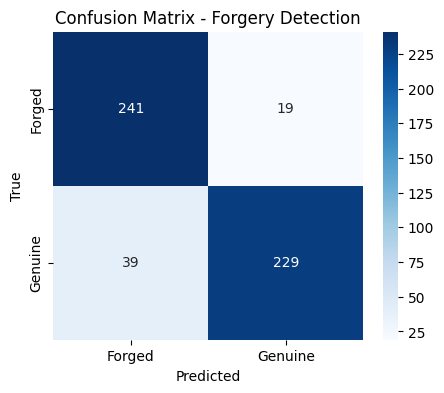

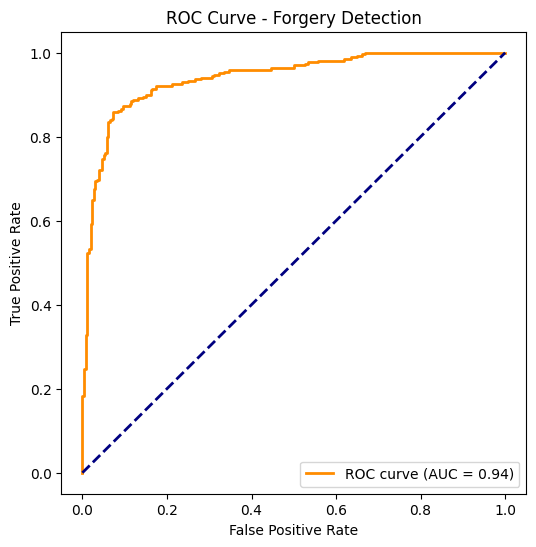

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from tensorflow.keras.models import load_model

# ---------------------------
# Load dataset
# ---------------------------
data = np.load("/content/drive/MyDrive/Signature Classification/data/signatures_dataset.npz", allow_pickle=True)

X = data["X"]
y_person_ids = data["person_ids"]
y_genuine = data["is_genuine"]

num_persons = len(np.unique(y_person_ids))

# Train/test split (same as training!)
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical

y_persons_oh = to_categorical(y_person_ids - 1, num_classes=num_persons)
y_genuine_oh = to_categorical(y_genuine, num_classes=2)

X_train, X_test, y_persons_train, y_persons_test, y_genuine_train, y_genuine_test = train_test_split(
    X, y_persons_oh, y_genuine_oh, test_size=0.2, random_state=42, stratify=y_person_ids
)

# ---------------------------
# Load the saved model
# ---------------------------
model = load_model("/content/drive/MyDrive/Signature Classification/data/signature_verification_model.h5")

# ---------------------------
# Evaluate
# ---------------------------
print("🔹 Model Evaluation on Test Set")
eval_results = model.evaluate(X_test, {"person_output": y_persons_test, "genuine_output": y_genuine_test})
print(eval_results)

# ---------------------------
# Predictions
# ---------------------------
y_pred_person, y_pred_genuine = model.predict(X_test)

y_true_person = np.argmax(y_persons_test, axis=1)
y_pred_person_cls = np.argmax(y_pred_person, axis=1)

y_true_genuine = np.argmax(y_genuine_test, axis=1)
y_pred_genuine_cls = np.argmax(y_pred_genuine, axis=1)

# ---------------------------
# Reports
# ---------------------------
print("\n📌 Person Classification Report")
print(classification_report(y_true_person, y_pred_person_cls))

print("\n📌 Forgery Detection Report")
print(classification_report(y_true_genuine, y_pred_genuine_cls))

# Confusion Matrix (Forgery)
cm = confusion_matrix(y_true_genuine, y_pred_genuine_cls)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Forged","Genuine"], yticklabels=["Forged","Genuine"])
plt.title("Confusion Matrix - Forgery Detection")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ---------------------------
# ROC Curve (Forgery Detection)
# ---------------------------
fpr, tpr, thresholds = roc_curve(y_true_genuine, y_pred_genuine[:,1])  # class 1 = Genuine
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0,1], [0,1], color="navy", lw=2, linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Forgery Detection")
plt.legend(loc="lower right")
plt.show()


<h1>Testing Using saved Model:

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from PIL import Image
import requests
from io import BytesIO

# ---------------------------
# 1. Load trained model
# ---------------------------
model = load_model("/content/drive/MyDrive/Signature Classification/data/signature_verification_model.h5")
print("✅ Model loaded successfully!")

# ---------------------------
# 2. Build person_id → name mapping from metadata.csv
# ---------------------------
metadata = pd.read_csv("/content/drive/MyDrive/Signature Classification/data/metadata.csv")
person_id_to_name = dict(zip(metadata["person_id"], metadata["person_name"]))
print("✅ Loaded person_id → person_name mapping")

# ---------------------------
# 3. Preprocess image
# ---------------------------
def preprocess_image(path_or_url):
    if path_or_url.startswith("http"):
        # Load image from URL
        response = requests.get(path_or_url)
        img = Image.open(BytesIO(response.content)).convert("L")
    else:
        # Load local image
        img = Image.open(path_or_url).convert("L")

    # Resize, normalize, and reshape
    img = img.resize((128, 128))
    img = np.array(img, dtype="float32") / 255.0
    img = np.expand_dims(img, axis=-1)  # (128,128,1)
    img = np.expand_dims(img, axis=0)   # (1,128,128,1)
    return img

# ---------------------------
# 4. Prediction function
# ---------------------------
def predict_signature(path_or_url):
    img = preprocess_image(path_or_url)
    pred_person_probs, pred_genuine_probs = model.predict(img)

    # Person prediction
    pred_person_id = np.argmax(pred_person_probs) + 1  # +1 if IDs started from 1
    person_name = person_id_to_name.get(pred_person_id, f"Person_{pred_person_id}")

    # Genuine/Forgery prediction
    pred_genuine_idx = np.argmax(pred_genuine_probs)
    forgery_status = "Genuine" if pred_genuine_idx == 1 else "Forged"

    return person_name, forgery_status

✅ Model loaded successfully!
✅ Loaded person_id → person_name mapping


In [ ]:
# ---------------------------
# 5. Example usage
# ---------------------------
if __name__ == "__main__":
    # Local test image
    img_path = r"/content/drive/MyDrive/Signature Classification/data/images/Aanya_forged_552.png"   # replace with your signature image path
    name, status = predict_signature(img_path)
    print(f"Predicted Person: {name}")
    print(f"Status: {status}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step
Predicted Person: Aanya
Status: Forged


<h2> Gradio UI

In [ ]:
import gradio as gr
import numpy as np
import pandas as pd
from tensorflow.keras.models import load_model
from PIL import Image

# --------------------------
# Load metadata.csv for mapping
# --------------------------
metadata = pd.read_csv("/content/drive/MyDrive/Signature Classification/data/metadata.csv")
metadata = metadata.drop_duplicates(subset=["person_id"])
person_name_map = dict(zip(metadata["person_id"], metadata["person_name"]))

# --------------------------
# Load model
# --------------------------
model = load_model("/content/drive/MyDrive/Signature Classification/data/signature_verification_model.h5")

# --------------------------
# Prediction function
# --------------------------
def predict_signature(image):
    # Preprocess
    img = image.convert("L").resize((128, 128))
    img = np.array(img) / 255.0
    img = np.expand_dims(img, axis=(0, -1))

    # Predict
    pred_person, pred_forgery = model.predict(img)

    # Mapping predicted person
    pred_person_idx = int(np.argmax(pred_person))
    pred_person_name = person_name_map.get(pred_person_idx, f"Unknown ID {pred_person_idx}")

    # Forgery prediction
    forgery_status = "Genuine" if np.argmax(pred_forgery) == 1 else "Forged"

    result = f"Person Name : {pred_person_name}\nStatus      : {forgery_status}"
    return result

# --------------------------
# Gradio UI (original layout)
# --------------------------
iface = gr.Interface(
    fn=predict_signature,
    inputs=gr.Image(type="pil", label="Upload Signature"),
    outputs=gr.Textbox(
        label="Prediction Result",
        lines=6,          # Makes box taller
        max_lines=10,     # Allows flexibility
        interactive=False
    ),
    title="Signature Verification",
    theme="default"      # Keep the classic layout
)

iface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://aa09729507def84b35.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


<h1>_______________________________END__________________________________________

<h1>Training Dataset with different Models

<h3>MODEL 1: Simple CNN

In [ ]:
# ================================================================
# MODEL 1: SIMPLE CNN (Multi-task: Person + Forgery classification)
# ================================================================
import os
from pathlib import Path
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
from PIL import Image
from tqdm import tqdm

# =========================
# Paths
# =========================
BASE_DIR = Path("/content/drive/MyDrive/Signature Classification/Comparative Study")
IMG_DIR = BASE_DIR / "/content/drive/MyDrive/Signature Classification/Comparative Study/images"
META_FILE = BASE_DIR / "/content/drive/MyDrive/Signature Classification/Comparative Study/metadata.csv"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Dataset
# =========================
class SignatureDataset(Dataset):
    def __init__(self, metadata, img_dir, transform=None):
        self.metadata = metadata
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        img_path = self.img_dir / row['filename']
        image = Image.open(img_path).convert('L')  # grayscale

        if self.transform:
            image = self.transform(image)

        label_person = row['person_label']
        label_forgery = row['is_genuine']

        return image, label_person, label_forgery

# =========================
# Load metadata
# =========================
metadata = pd.read_csv(META_FILE)
le = LabelEncoder()
metadata['person_label'] = le.fit_transform(metadata['person_name'])

# =========================
# Train-test split
# =========================
from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(metadata, test_size=0.2, stratify=metadata['person_label'], random_state=42)

# =========================
# Transforms
# =========================
transform = transforms.Compose([
    transforms.Resize((155, 220)),
    transforms.ToTensor(),
])

train_dataset = SignatureDataset(train_df, IMG_DIR, transform)
val_dataset = SignatureDataset(val_df, IMG_DIR, transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# =========================
# Model Definition
# =========================
class SimpleCNN(nn.Module):
    def __init__(self, num_persons):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(), nn.MaxPool2d(2),
        )
        self.flatten = nn.Flatten()
        self.fc_person = nn.Linear(128 * 19 * 27, num_persons)
        self.fc_forgery = nn.Linear(128 * 19 * 27, 2)

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        out_person = self.fc_person(x)
        out_forgery = self.fc_forgery(x)
        return out_person, out_forgery

# =========================
# Initialize Model
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_persons = metadata['person_label'].nunique()
model = SimpleCNN(num_persons).to(device)

criterion_person = nn.CrossEntropyLoss()
criterion_forgery = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3)

# =========================
# Training Loop
# =========================
EPOCHS = 10
for epoch in range(EPOCHS):
    model.train()
    total_loss, total_acc = 0, 0
    for imgs, label_person, label_forgery in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, label_person, label_forgery = imgs.to(device), label_person.to(device), label_forgery.to(device)

        optimizer.zero_grad()
        out_person, out_forgery = model(imgs)

        loss_person = criterion_person(out_person, label_person)
        loss_forgery = criterion_forgery(out_forgery, label_forgery)
        loss = loss_person + loss_forgery
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {total_loss/len(train_loader):.4f}")

# =========================
# Evaluation
# =========================
model.eval()
all_preds_person, all_labels_person = [], []
all_preds_forgery, all_labels_forgery = [], []

with torch.no_grad():
    for imgs, label_person, label_forgery in val_loader:
        imgs = imgs.to(device)
        out_person, out_forgery = model(imgs)
        all_preds_person.extend(out_person.argmax(1).cpu().numpy())
        all_labels_person.extend(label_person.numpy())
        all_preds_forgery.extend(out_forgery.argmax(1).cpu().numpy())
        all_labels_forgery.extend(label_forgery.numpy())

print("\n🧠 PERSON CLASSIFICATION REPORT")
print(classification_report(all_labels_person, all_preds_person, target_names=le.classes_))

print("\n✍️ FORGERY DETECTION REPORT")
print(classification_report(all_labels_forgery, all_preds_forgery, target_names=["Forged", "Genuine"]))

# =========================
# Save Model
# =========================
torch.save(model.state_dict(), MODEL_DIR / "model_cnn.pt")
print("✅ Model saved to:", MODEL_DIR / "model_cnn.pt")


Epoch 1/10: 100%|██████████| 66/66 [00:10<00:00,  6.01it/s]


Epoch [1/10] - Loss: 4.2013


Epoch 2/10: 100%|██████████| 66/66 [00:11<00:00,  5.92it/s]


Epoch [2/10] - Loss: 1.6346


Epoch 3/10: 100%|██████████| 66/66 [00:11<00:00,  5.88it/s]


...

Epoch [8/10] - Loss: 0.4197


Epoch 9/10: 100%|██████████| 66/66 [00:13<00:00,  4.85it/s]


Epoch [9/10] - Loss: 0.3579


Epoch 10/10: 100%|██████████| 66/66 [00:11<00:00,  5.89it/s]


Epoch [10/10] - Loss: 0.3202

🧠 PERSON CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Aanya       0.83      1.00      0.91        10
       Aarav       1.00      0.70      0.82        10
       Abhay       1.00      0.90      0.95        10
       Aditi       0.89      0.89      0.89         9
      Aditya       0.82      1.00      0.90         9
       Akhil       1.00      1.00      1.00         9
      Ananya       1.00      1.00      1.00         9
      Aniket       0.73      0.80      0.76        10
       Arjun       0.70      0.78      0.74         9
       Aryan       0.90      0.90      0.90        10
     Bhavana       1.00      1.00      1.00        10
      Chetan       0.90      0.90      0.90        10
         Dev       0.80      0.89      0.84         9
       Divya       0.82      1.00      0.90         9
        Diya       0.83      0.50      0.62        10
        Esha       0.50      0.50      0.50        10
      Gaurav       0

<h3>MODEL 2: PyTorch ResNet18

In [ ]:
# ================================================================
# MODEL 2: ResNet18 (Multi-task: Person + Forgery classification)
# ================================================================
import os
from pathlib import Path
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

# =========================
# Paths
# =========================
BASE_DIR = Path("/content/drive/MyDrive/Signature Classification/Comparative Study")
IMG_DIR = BASE_DIR / "/content/drive/MyDrive/Signature Classification/Comparative Study/images"
META_FILE = BASE_DIR / "/content/drive/MyDrive/Signature Classification/Comparative Study/metadata.csv"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Dataset
# =========================
class SignatureDataset(Dataset):
    def __init__(self, metadata, img_dir, transform=None):
        self.metadata = metadata
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        img_path = self.img_dir / row['filename']
        image = Image.open(img_path).convert('L')  # grayscale
        image = image.convert('RGB')  # ResNet expects 3 channels

        if self.transform:
            image = self.transform(image)

        label_person = row['person_label']
        label_forgery = row['is_genuine']
        return image, label_person, label_forgery

# =========================
# Load metadata
# =========================
metadata = pd.read_csv(META_FILE)
le = LabelEncoder()
metadata['person_label'] = le.fit_transform(metadata['person_name'])

# =========================
# Train-test split
# =========================
train_df, val_df = train_test_split(metadata, test_size=0.2, stratify=metadata['person_label'], random_state=42)

# =========================
# Transforms
# =========================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = SignatureDataset(train_df, IMG_DIR, transform)
val_dataset = SignatureDataset(val_df, IMG_DIR, transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# =========================
# Model Definition
# =========================
class MultiTaskResNet18(nn.Module):
    def __init__(self, num_persons):
        super(MultiTaskResNet18, self).__init__()
        self.backbone = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
        self.backbone.fc = nn.Identity()  # remove last layer
        self.fc_person = nn.Linear(512, num_persons)
        self.fc_forgery = nn.Linear(512, 2)

    def forward(self, x):
        x = self.backbone(x)
        out_person = self.fc_person(x)
        out_forgery = self.fc_forgery(x)
        return out_person, out_forgery

# =========================
# Initialize Model
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_persons = metadata['person_label'].nunique()
model = MultiTaskResNet18(num_persons).to(device)

criterion_person = nn.CrossEntropyLoss()
criterion_forgery = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# =========================
# Training Loop
# =========================
EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, label_person, label_forgery in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, label_person, label_forgery = imgs.to(device), label_person.to(device), label_forgery.to(device)
        optimizer.zero_grad()

        out_person, out_forgery = model(imgs)
        loss_person = criterion_person(out_person, label_person)
        loss_forgery = criterion_forgery(out_forgery, label_forgery)
        loss = loss_person + loss_forgery

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {running_loss/len(train_loader):.4f}")

# =========================
# Evaluation
# =========================
model.eval()
all_preds_person, all_labels_person = [], []
all_preds_forgery, all_labels_forgery = [], []

with torch.no_grad():
    for imgs, label_person, label_forgery in val_loader:
        imgs = imgs.to(device)
        out_person, out_forgery = model(imgs)

        all_preds_person.extend(out_person.argmax(1).cpu().numpy())
        all_labels_person.extend(label_person.numpy())

        all_preds_forgery.extend(out_forgery.argmax(1).cpu().numpy())
        all_labels_forgery.extend(label_forgery.numpy())

print("\n🧠 PERSON CLASSIFICATION REPORT")
print(classification_report(all_labels_person, all_preds_person, target_names=le.classes_))

print("\n✍️ FORGERY DETECTION REPORT")
print(classification_report(all_labels_forgery, all_preds_forgery, target_names=["Forged", "Genuine"]))

# =========================
# Save Model
# =========================
torch.save(model.state_dict(), MODEL_DIR / "model_resnet18.pt")
print("✅ Model saved to:", MODEL_DIR / "model_resnet18.pt")


Epoch 1/20: 100%|██████████| 66/66 [00:15<00:00,  4.13it/s]


Epoch [1/20] - Loss: 2.6844


Epoch 2/20: 100%|██████████| 66/66 [00:15<00:00,  4.18it/s]


Epoch [2/20] - Loss: 0.6329


Epoch 3/20: 100%|██████████| 66/66 [00:15<00:00,  4.15it/s]


...

Epoch [18/20] - Loss: 0.0110


Epoch 19/20: 100%|██████████| 66/66 [00:16<00:00,  4.11it/s]


Epoch [19/20] - Loss: 0.0138


Epoch 20/20: 100%|██████████| 66/66 [00:15<00:00,  4.15it/s]


Epoch [20/20] - Loss: 0.0154

🧠 PERSON CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Aanya       1.00      1.00      1.00        10
       Aarav       1.00      1.00      1.00        10
       Abhay       1.00      1.00      1.00        10
       Aditi       1.00      1.00      1.00         9
      Aditya       1.00      1.00      1.00         9
       Akhil       1.00      1.00      1.00         9
      Ananya       1.00      1.00      1.00         9
      Aniket       1.00      0.90      0.95        10
       Arjun       1.00      1.00      1.00         9
       Aryan       1.00      1.00      1.00        10
     Bhavana       1.00      1.00      1.00        10
      Chetan       1.00      1.00      1.00        10
         Dev       1.00      1.00      1.00         9
       Divya       1.00      1.00      1.00         9
        Diya       1.00      1.00      1.00        10
        Esha       1.00      1.00      1.00        10
      Gaurav       1

<h3>MODEL 3: VGG16 (Multi-Task)

In [ ]:
# ================================================================
# MODEL 3: VGG16 (Multi-task: Person + Forgery classification)
# ================================================================
import os
from pathlib import Path
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

# =========================
# Paths
# =========================
BASE_DIR = Path("/content/drive/MyDrive/Signature Classification/Comparative Study")
IMG_DIR = BASE_DIR / "/content/drive/MyDrive/Signature Classification/Comparative Study/images"
META_FILE = BASE_DIR / "/content/drive/MyDrive/Signature Classification/Comparative Study/metadata.csv"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Dataset Class
# =========================
class SignatureDataset(Dataset):
    def __init__(self, metadata, img_dir, transform=None):
        self.metadata = metadata
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        img_path = self.img_dir / row['filename']
        image = Image.open(img_path).convert('L').convert('RGB')
        if self.transform:
            image = self.transform(image)
        label_person = row['person_label']
        label_forgery = row['is_genuine']
        return image, label_person, label_forgery

# =========================
# Load Metadata
# =========================
metadata = pd.read_csv(META_FILE)
le = LabelEncoder()
metadata['person_label'] = le.fit_transform(metadata['person_name'])

# =========================
# Train-Test Split
# =========================
train_df, val_df = train_test_split(metadata, test_size=0.2, stratify=metadata['person_label'], random_state=42)

# =========================
# Transforms
# =========================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = SignatureDataset(train_df, IMG_DIR, transform)
val_dataset = SignatureDataset(val_df, IMG_DIR, transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# =========================
# Model Definition
# =========================
class MultiTaskVGG16(nn.Module):
    def __init__(self, num_persons):
        super(MultiTaskVGG16, self).__init__()
        self.backbone = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
        self.backbone.classifier = nn.Identity()  # remove default classifier
        self.fc_person = nn.Linear(512 * 7 * 7, num_persons)
        self.fc_forgery = nn.Linear(512 * 7 * 7, 2)

    def forward(self, x):
        x = self.backbone.features(x)
        x = torch.flatten(x, 1)
        out_person = self.fc_person(x)
        out_forgery = self.fc_forgery(x)
        return out_person, out_forgery

# =========================
# Initialize Model
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_persons = metadata['person_label'].nunique()
model = MultiTaskVGG16(num_persons).to(device)

criterion_person = nn.CrossEntropyLoss()
criterion_forgery = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# =========================
# Training Loop
# =========================
EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, label_person, label_forgery in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, label_person, label_forgery = imgs.to(device), label_person.to(device), label_forgery.to(device)
        optimizer.zero_grad()

        out_person, out_forgery = model(imgs)
        loss_person = criterion_person(out_person, label_person)
        loss_forgery = criterion_forgery(out_forgery, label_forgery)
        loss = loss_person + loss_forgery

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {running_loss/len(train_loader):.4f}")

# =========================
# Evaluation
# =========================
model.eval()
all_preds_person, all_labels_person = [], []
all_preds_forgery, all_labels_forgery = [], []

with torch.no_grad():
    for imgs, label_person, label_forgery in val_loader:
        imgs = imgs.to(device)
        out_person, out_forgery = model(imgs)

        all_preds_person.extend(out_person.argmax(1).cpu().numpy())
        all_labels_person.extend(label_person.numpy())

        all_preds_forgery.extend(out_forgery.argmax(1).cpu().numpy())
        all_labels_forgery.extend(label_forgery.numpy())

print("\n🧠 PERSON CLASSIFICATION REPORT")
print(classification_report(all_labels_person, all_preds_person, target_names=le.classes_))

print("\n✍️ FORGERY DETECTION REPORT")
print(classification_report(all_labels_forgery, all_preds_forgery, target_names=["Forged", "Genuine"]))

# =========================
# Save Model
# =========================
torch.save(model.state_dict(), MODEL_DIR / "model_vgg16.pt")
print("✅ Model saved to:", MODEL_DIR / "model_vgg16.pt")


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:04<00:00, 120MB/s]
Epoch 1/20: 100%|██████████| 66/66 [00:37<00:00,  1.78it/s]


Epoch [1/20] - Loss: 1.3648


Epoch 2/20: 100%|██████████| 66/66 [00:37<00:00,  1.77it/s]


Epoch [2/20] - Loss: 0.1572


...

Epoch [18/20] - Loss: 0.0000


Epoch 19/20: 100%|██████████| 66/66 [00:37<00:00,  1.75it/s]


Epoch [19/20] - Loss: 0.0000


Epoch 20/20: 100%|██████████| 66/66 [00:37<00:00,  1.77it/s]


Epoch [20/20] - Loss: 0.0000

🧠 PERSON CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Aanya       1.00      1.00      1.00        10
       Aarav       1.00      1.00      1.00        10
       Abhay       1.00      1.00      1.00        10
       Aditi       1.00      1.00      1.00         9
      Aditya       1.00      1.00      1.00         9
       Akhil       1.00      1.00      1.00         9
      Ananya       1.00      1.00      1.00         9
      Aniket       1.00      1.00      1.00        10
       Arjun       1.00      1.00      1.00         9
       Aryan       1.00      1.00      1.00        10
     Bhavana       1.00      1.00      1.00        10
      Chetan       1.00      1.00      1.00        10
         Dev       1.00      1.00      1.00         9
       Divya       1.00      1.00      1.00         9
        Diya       1.00      1.00      1.00        10
        Esha       1.00      1.00      1.00        10
      Gaurav       1

<h3>MODEL 4: MobileNetV2

In [ ]:
# ================================================================
# MODEL 4: MobileNetV2 (Multi-task: Person + Forgery classification)
# ================================================================
import os
from pathlib import Path
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report
from sklearn.model_selection import train_test_split
from PIL import Image
from tqdm import tqdm

# =========================
# Paths
# =========================
BASE_DIR = Path("/content/drive/MyDrive/Signature Classification/Comparative Study")
IMG_DIR = BASE_DIR / "/content/drive/MyDrive/Signature Classification/Comparative Study/images"
META_FILE = BASE_DIR / "/content/drive/MyDrive/Signature Classification/Comparative Study/metadata.csv"
MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# =========================
# Dataset
# =========================
class SignatureDataset(Dataset):
    def __init__(self, metadata, img_dir, transform=None):
        self.metadata = metadata
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        row = self.metadata.iloc[idx]
        img_path = self.img_dir / row['filename']
        image = Image.open(img_path).convert('L').convert('RGB')  # 3-channel for MobileNet
        if self.transform:
            image = self.transform(image)
        label_person = row['person_label']
        label_forgery = row['is_genuine']
        return image, label_person, label_forgery

# =========================
# Load metadata
# =========================
metadata = pd.read_csv(META_FILE)
le = LabelEncoder()
metadata['person_label'] = le.fit_transform(metadata['person_name'])

# =========================
# Train-test split
# =========================
train_df, val_df = train_test_split(metadata, test_size=0.2, stratify=metadata['person_label'], random_state=42)

# =========================
# Transforms
# =========================
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_dataset = SignatureDataset(train_df, IMG_DIR, transform)
val_dataset = SignatureDataset(val_df, IMG_DIR, transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)

# =========================
# Model Definition
# =========================
class MultiTaskMobileNetV2(nn.Module):
    def __init__(self, num_persons):
        super(MultiTaskMobileNetV2, self).__init__()
        self.backbone = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.DEFAULT)
        self.backbone.classifier = nn.Identity()
        self.fc_person = nn.Linear(1280, num_persons)
        self.fc_forgery = nn.Linear(1280, 2)

    def forward(self, x):
        x = self.backbone(x)
        out_person = self.fc_person(x)
        out_forgery = self.fc_forgery(x)
        return out_person, out_forgery

# =========================
# Initialize Model
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_persons = metadata['person_label'].nunique()
model = MultiTaskMobileNetV2(num_persons).to(device)

criterion_person = nn.CrossEntropyLoss()
criterion_forgery = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# =========================
# Training Loop
# =========================
EPOCHS = 20
for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0
    for imgs, label_person, label_forgery in tqdm(train_loader, desc=f"Epoch {epoch+1}/{EPOCHS}"):
        imgs, label_person, label_forgery = imgs.to(device), label_person.to(device), label_forgery.to(device)
        optimizer.zero_grad()

        out_person, out_forgery = model(imgs)
        loss_person = criterion_person(out_person, label_person)
        loss_forgery = criterion_forgery(out_forgery, label_forgery)
        loss = loss_person + loss_forgery

        loss.backward()
        optimizer.step()
        running_loss += loss.item()

    print(f"Epoch [{epoch+1}/{EPOCHS}] - Loss: {running_loss/len(train_loader):.4f}")

# =========================
# Evaluation
# =========================
model.eval()
all_preds_person, all_labels_person = [], []
all_preds_forgery, all_labels_forgery = [], []

with torch.no_grad():
    for imgs, label_person, label_forgery in val_loader:
        imgs = imgs.to(device)
        out_person, out_forgery = model(imgs)

        all_preds_person.extend(out_person.argmax(1).cpu().numpy())
        all_labels_person.extend(label_person.numpy())

        all_preds_forgery.extend(out_forgery.argmax(1).cpu().numpy())
        all_labels_forgery.extend(label_forgery.numpy())

print("\n🧠 PERSON CLASSIFICATION REPORT")
print(classification_report(all_labels_person, all_preds_person, target_names=le.classes_))

print("\n✍️ FORGERY DETECTION REPORT")
print(classification_report(all_labels_forgery, all_preds_forgery, target_names=["Forged", "Genuine"]))

# =========================
# Save Model
# =========================
torch.save(model.state_dict(), MODEL_DIR / "model_mobilenetv2.pt")
print("✅ Model saved to:", MODEL_DIR / "model_mobilenetv2.pt")


Downloading: "https://download.pytorch.org/models/mobilenet_v2-7ebf99e0.pth" to /root/.cache/torch/hub/checkpoints/mobilenet_v2-7ebf99e0.pth


100%|██████████| 13.6M/13.6M [00:00<00:00, 132MB/s]
Epoch 1/20: 100%|██████████| 66/66 [00:17<00:00,  3.88it/s]


Epoch [1/20] - Loss: 4.3354


Epoch 2/20: 100%|██████████| 66/66 [00:16<00:00,  4.00it/s]


Epoch [2/20] - Loss: 3.0584


...

Epoch [18/20] - Loss: 0.0195


Epoch 19/20: 100%|██████████| 66/66 [00:16<00:00,  3.94it/s]


Epoch [19/20] - Loss: 0.0182


Epoch 20/20: 100%|██████████| 66/66 [00:16<00:00,  4.02it/s]


Epoch [20/20] - Loss: 0.0296

🧠 PERSON CLASSIFICATION REPORT
              precision    recall  f1-score   support

       Aanya       0.91      1.00      0.95        10
       Aarav       1.00      0.70      0.82        10
       Abhay       1.00      1.00      1.00        10
       Aditi       1.00      1.00      1.00         9
      Aditya       1.00      1.00      1.00         9
       Akhil       0.33      1.00      0.50         9
      Ananya       1.00      0.89      0.94         9
      Aniket       1.00      0.30      0.46        10
       Arjun       0.90      1.00      0.95         9
       Aryan       0.45      1.00      0.62        10
     Bhavana       1.00      1.00      1.00        10
      Chetan       1.00      1.00      1.00        10
         Dev       1.00      0.78      0.88         9
       Divya       1.00      1.00      1.00         9
        Diya       0.91      1.00      0.95        10
        Esha       0.90      0.90      0.90        10
      Gaurav       1

<h1>Models Comparison Study

In [ ]:
from pathlib import Path
import pandas as pd

# Set paths
BASE_DIR = Path("/content/drive/MyDrive/Signature Classification/Comparative Study")
IMG_DIR = BASE_DIR / "/content/drive/MyDrive/Signature Classification/Comparative Study/images"
META_FILE = BASE_DIR / "/content/drive/MyDrive/Signature Classification/Comparative Study/metadata.csv"
MODEL_DIR = BASE_DIR / "models"

MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Load metadata
metadata = pd.read_csv(META_FILE)
print("✅ Metadata loaded with", len(metadata), "entries")
print(metadata.head())


✅ Metadata loaded with 2640 entries
              filename  person_id person_name  is_genuine    label
0   Uday_genuine_0.png          0        Uday           1  genuine
1   Uday_genuine_1.png          0        Uday           1  genuine
2  Uday_genuine_10.png          0        Uday           1  genuine
3  Uday_genuine_11.png          0        Uday           1  genuine
4  Uday_genuine_12.png          0        Uday           1  genuine


<h3>Common Setup

In [ ]:
# =============================
# COMMON SETUP
# =============================
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image
import pandas as pd
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# =============================
# Dataset Class
# =============================
class SignatureDataset(Dataset):
    def __init__(self, csv_path, img_dir, transform=None):
        self.data = pd.read_csv(csv_path)
        self.img_dir = img_dir
        self.transform = transform

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        row = self.data.iloc[idx]
        img_path = os.path.join(self.img_dir, row['filename'])
        image = Image.open(img_path).convert('RGB')
        label_person = int(row['person_id'])
        label_forgery = int(row['is_genuine'])
        if self.transform:
            image = self.transform(image)
        return image, label_person, label_forgery

# =============================
# Dataloaders
# =============================
def get_dataloaders(csv_path, img_dir, batch_size=32):
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
    ])
    dataset = SignatureDataset(csv_path, img_dir, transform)
    val_size = int(0.2 * len(dataset))
    train_size = len(dataset) - val_size
    train_ds, val_ds = torch.utils.data.random_split(dataset, [train_size, val_size])
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False)
    return train_loader, val_loader


<h3>Training & Evaluation Function

In [ ]:
# =============================
# TRAINING FUNCTION
# =============================
def train_model(model, train_loader, val_loader, num_epochs, device, save_path):
    criterion1 = nn.CrossEntropyLoss()
    criterion2 = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

    for epoch in range(num_epochs):
        model.train()
        total_loss, correct_person, correct_forgery, total = 0, 0, 0, 0

        for imgs, person_labels, forgery_labels in train_loader:
            imgs, person_labels, forgery_labels = imgs.to(device), person_labels.to(device), forgery_labels.to(device)
            optimizer.zero_grad()
            out_person, out_forgery = model(imgs)
            loss = criterion1(out_person, person_labels) + criterion2(out_forgery, forgery_labels)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            correct_person += (out_person.argmax(1) == person_labels).sum().item()
            correct_forgery += (out_forgery.argmax(1) == forgery_labels).sum().item()
            total += person_labels.size(0)

        print(f"Epoch {epoch+1}/{num_epochs} | Loss: {total_loss/len(train_loader):.4f} | "
              f"Person Acc: {correct_person/total:.2f} | Forgery Acc: {correct_forgery/total:.2f}")

    torch.save(model.state_dict(), save_path)
    print(f"✅ Model saved to {save_path}")
    return model

# =============================
# EVALUATION FUNCTION
# =============================
def evaluate_model(model, val_loader, device, num_persons):
    model.eval()
    y_true_person, y_pred_person = [], []
    y_true_forgery, y_pred_forgery = [], []

    with torch.no_grad():
        for imgs, person_labels, forgery_labels in val_loader:
            imgs = imgs.to(device)
            out_person, out_forgery = model(imgs)
            y_true_person.extend(person_labels.tolist())
            y_true_forgery.extend(forgery_labels.tolist())
            y_pred_person.extend(out_person.argmax(1).cpu().tolist())
            y_pred_forgery.extend(out_forgery.argmax(1).cpu().tolist())

    print("\n--- Forgery Classification Report ---")
    print(classification_report(y_true_forgery, y_pred_forgery, target_names=["Forged", "Genuine"]))
    metrics = {
        "Accuracy": accuracy_score(y_true_forgery, y_pred_forgery),
        "Precision": precision_score(y_true_forgery, y_pred_forgery),
        "Recall": recall_score(y_true_forgery, y_pred_forgery),
        "F1": f1_score(y_true_forgery, y_pred_forgery)
    }
    return metrics


<h2>Model 1: Custom CNN

In [ ]:
# =============================
# MODEL 1 — CUSTOM CNN
# =============================
class CustomCNN(nn.Module):
    def __init__(self, num_persons):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, 3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Flatten()
        )
        self.fc_person = nn.Linear(64 * 56 * 56, num_persons)
        self.fc_forgery = nn.Linear(64 * 56 * 56, 2)

    def forward(self, x):
        x = self.features(x)
        return self.fc_person(x), self.fc_forgery(x)


In [ ]:
class ResNet18Multi(nn.Module):
    def __init__(self, num_persons):
        super().__init__()
        base = models.resnet18(weights="IMAGENET1K_V1")
        in_features = base.fc.in_features
        base.fc = nn.Identity()
        self.backbone = base
        self.fc_person = nn.Linear(in_features, num_persons)
        self.fc_forgery = nn.Linear(in_features, 2)

    def forward(self, x):
        features = self.backbone(x)
        return self.fc_person(features), self.fc_forgery(features)


In [ ]:
class MobileNetMulti(nn.Module):
    def __init__(self, num_persons):
        super().__init__()
        base = models.mobilenet_v2(weights="IMAGENET1K_V1")
        in_features = base.classifier[1].in_features
        base.classifier = nn.Identity()
        self.backbone = base
        self.fc_person = nn.Linear(in_features, num_persons)
        self.fc_forgery = nn.Linear(in_features, 2)

    def forward(self, x):
        features = self.backbone(x)
        return self.fc_person(features), self.fc_forgery(features)


In [ ]:
class EfficientNetMulti(nn.Module):
    def __init__(self, num_persons):
        super().__init__()
        base = models.efficientnet_b0(weights="IMAGENET1K_V1")
        in_features = base.classifier[1].in_features
        base.classifier = nn.Identity()
        self.backbone = base
        self.fc_person = nn.Linear(in_features, num_persons)
        self.fc_forgery = nn.Linear(in_features, 2)

    def forward(self, x):
        features = self.backbone(x)
        return self.fc_person(features), self.fc_forgery(features)


Epoch 1/10 | Loss: 4.9721 | Person Acc: 0.05 | Forgery Acc: 0.55
Epoch 2/10 | Loss: 3.6847 | Person Acc: 0.42 | Forgery Acc: 0.68
Epoch 3/10 | Loss: 2.1133 | Person Acc: 0.74 | Forgery Acc: 0.72
Epoch 4/10 | Loss: 1.2789 | Person Acc: 0.86 | Forgery Acc: 0.76
Epoch 5/10 | Loss: 0.9184 | Person Acc: 0.93 | Forgery Acc: 0.77
Epoch 6/10 | Loss: 0.7105 | Person Acc: 0.96 | Forgery Acc: 0.80
Epoch 7/10 | Loss: 0.5761 | Person Acc: 0.98 | Forgery Acc: 0.82
Epoch 8/10 | Loss: 0.4857 | Person Acc: 0.99 | Forgery Acc: 0.82
Epoch 9/10 | Loss: 0.4372 | Person Acc: 1.00 | Forgery Acc: 0.84
Epoch 10/10 | Loss: 0.4035 | Person Acc: 1.00 | Forgery Acc: 0.85
✅ Model saved to custom_cnn.pth

--- Forgery Classification Report ---
              precision    recall  f1-score   support

      Forged       0.73      0.76      0.74       262
     Genuine       0.75      0.72      0.74       266

    accuracy                           0.74       528
   macro avg       0.74      0.74      0.74       528
weight

100%|██████████| 44.7M/44.7M [00:00<00:00, 140MB/s]


Epoch 1/10 | Loss: 2.7164 | Person Acc: 0.61 | Forgery Acc: 0.82
Epoch 2/10 | Loss: 0.6323 | Person Acc: 0.99 | Forgery Acc: 0.97
Epoch 3/10 | Loss: 0.2228 | Person Acc: 1.00 | Forgery Acc: 0.99
Epoch 4/10 | Loss: 0.1051 | Person Acc: 1.00 | Forgery Acc: 1.00
Epoch 5/10 | Loss: 0.0704 | Person Acc: 1.00 | Forgery Acc: 1.00
Epoch 6/10 | Loss: 0.0470 | Person Acc: 1.00 | Forgery Acc: 1.00
Epoch 7/10 | Loss: 0.0355 | Person Acc: 1.00 | Forgery Acc: 1.00
Epoch 8/10 | Loss: 0.0280 | Person Acc: 1.00 | Forgery Acc: 1.00
Epoch 9/10 | Loss: 0.0223 | Person Acc: 1.00 | Forgery Acc: 1.00
Epoch 10/10 | Loss: 0.0176 | Person Acc: 1.00 | Forgery Acc: 1.00
✅ Model saved to resnet18.pth

--- Forgery Classification Report ---
              precision    recall  f1-score   support

      Forged       0.96      1.00      0.98       262
     Genuine       1.00      0.96      0.98       266

    accuracy                           0.98       528
   macro avg       0.98      0.98      0.98       528
weighted

100%|██████████| 13.6M/13.6M [00:00<00:00, 208MB/s]


Epoch 1/10 | Loss: 3.3709 | Person Acc: 0.51 | Forgery Acc: 0.78
Epoch 2/10 | Loss: 1.3460 | Person Acc: 0.93 | Forgery Acc: 0.92
Epoch 3/10 | Loss: 0.5509 | Person Acc: 0.98 | Forgery Acc: 0.98
Epoch 4/10 | Loss: 0.2651 | Person Acc: 1.00 | Forgery Acc: 0.99
Epoch 5/10 | Loss: 0.1526 | Person Acc: 1.00 | Forgery Acc: 0.99
Epoch 6/10 | Loss: 0.1030 | Person Acc: 1.00 | Forgery Acc: 1.00
Epoch 7/10 | Loss: 0.0732 | Person Acc: 1.00 | Forgery Acc: 1.00
Epoch 8/10 | Loss: 0.0489 | Person Acc: 1.00 | Forgery Acc: 1.00
Epoch 9/10 | Loss: 0.0398 | Person Acc: 1.00 | Forgery Acc: 1.00
Epoch 10/10 | Loss: 0.0427 | Person Acc: 1.00 | Forgery Acc: 1.00
✅ Model saved to mobilenetv2.pth

--- Forgery Classification Report ---
              precision    recall  f1-score   support

      Forged       0.97      0.93      0.95       262
     Genuine       0.93      0.97      0.95       266

    accuracy                           0.95       528
   macro avg       0.95      0.95      0.95       528
weigh

100%|██████████| 20.5M/20.5M [00:00<00:00, 135MB/s]


Epoch 1/10 | Loss: 4.1640 | Person Acc: 0.31 | Forgery Acc: 0.72
Epoch 2/10 | Loss: 2.7389 | Person Acc: 0.71 | Forgery Acc: 0.83
Epoch 3/10 | Loss: 1.5064 | Person Acc: 0.87 | Forgery Acc: 0.89
Epoch 4/10 | Loss: 0.8012 | Person Acc: 0.95 | Forgery Acc: 0.94
Epoch 5/10 | Loss: 0.4712 | Person Acc: 0.98 | Forgery Acc: 0.96
Epoch 6/10 | Loss: 0.3120 | Person Acc: 0.98 | Forgery Acc: 0.97
Epoch 7/10 | Loss: 0.2230 | Person Acc: 0.99 | Forgery Acc: 0.98
Epoch 8/10 | Loss: 0.1602 | Person Acc: 0.99 | Forgery Acc: 0.99
Epoch 9/10 | Loss: 0.1147 | Person Acc: 1.00 | Forgery Acc: 0.99
Epoch 10/10 | Loss: 0.1003 | Person Acc: 1.00 | Forgery Acc: 0.99
✅ Model saved to efficientnetb0.pth

--- Forgery Classification Report ---
              precision    recall  f1-score   support

      Forged       0.94      0.85      0.89       262
     Genuine       0.87      0.94      0.90       266

    accuracy                           0.90       528
   macro avg       0.90      0.90      0.90       528
we

<Figure size 1000x500 with 0 Axes>

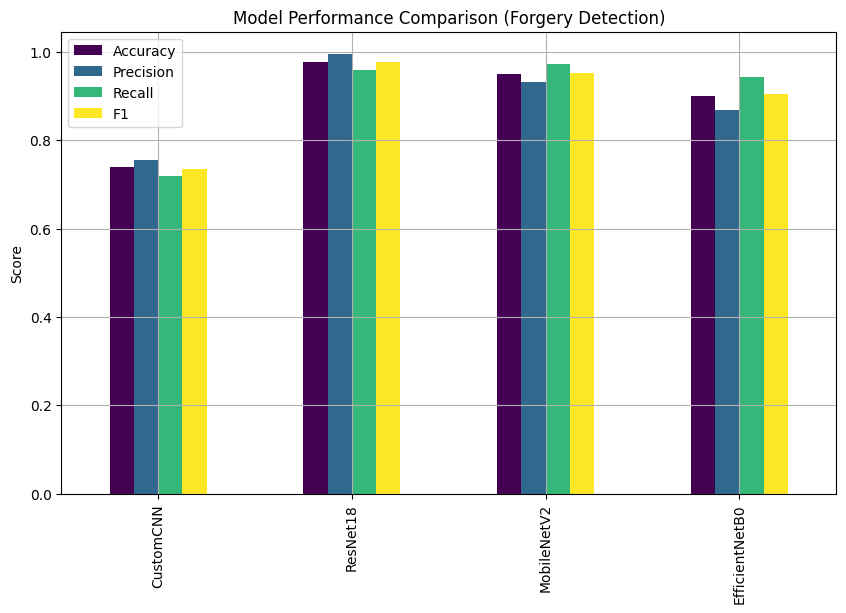

In [ ]:
# =============================
# TRAIN AND COMPARE
# =============================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
csv_path = "/content/drive/MyDrive/Signature Classification/Comparative Study/metadata.csv"
img_dir = "/content/drive/MyDrive/Signature Classification/Comparative Study/images"
train_loader, val_loader = get_dataloaders(csv_path, img_dir, batch_size=32)

num_persons = len(pd.read_csv(csv_path)["person_id"].unique())
results = {}

# --- Custom CNN
cnn_model = CustomCNN(num_persons).to(device)
cnn_model = train_model(cnn_model, train_loader, val_loader, 10, device, "custom_cnn.pth")
results["CustomCNN"] = evaluate_model(cnn_model, val_loader, device, num_persons)

# --- ResNet18
resnet_model = ResNet18Multi(num_persons).to(device)
resnet_model = train_model(resnet_model, train_loader, val_loader, 10, device, "resnet18.pth")
results["ResNet18"] = evaluate_model(resnet_model, val_loader, device, num_persons)

# --- MobileNetV2
mobile_model = MobileNetMulti(num_persons).to(device)
mobile_model = train_model(mobile_model, train_loader, val_loader, 10, device, "mobilenetv2.pth")
results["MobileNetV2"] = evaluate_model(mobile_model, val_loader, device, num_persons)

# --- EfficientNetB0
eff_model = EfficientNetMulti(num_persons).to(device)
eff_model = train_model(eff_model, train_loader, val_loader, 10, device, "efficientnetb0.pth")
results["EfficientNetB0"] = evaluate_model(eff_model, val_loader, device, num_persons)

# --- Comparison Table
results_df = pd.DataFrame(results).T
print("\n🔍 Model Comparison:\n")
print(results_df)

# --- Bar Chart
plt.figure(figsize=(10,5))
results_df.plot(kind='bar', figsize=(10,6), colormap='viridis')
plt.title("Model Performance Comparison (Forgery Detection)")
plt.ylabel("Score")
plt.grid(True)
plt.show()


In [ ]:
import os
save_dir = "/content/drive/MyDrive/Signature Classification/Comparative Study/models"
os.makedirs(save_dir, exist_ok=True)
print("✅ Save directory ready:", save_dir)


✅ Save directory ready: /content/drive/MyDrive/Signature Classification/Comparative Study/models
